# Denoising AutoEncoder（CIFAR-10）

このノートブックでは、CIFAR-10を用いたDenoising AutoEncoderの学習と、ボトルネック特徴量のk-meansクラスタリングを行います。

In [ ]:
# 必要なライブラリ
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.cluster import KMeans

# 日本語フォント設定（利用可能なものを自動選択）
def set_japanese_font():
    candidates = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "TakaoGothic",
        "Yu Gothic",
        "Hiragino Sans",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_japanese_font()

# 再現性のためのシード固定
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. データ準備と前処理（CIFAR-10）

CIFAR-10を読み込み、正規化とデータローダを作成します。入力にはノイズを付与し、出力は元画像になるようにします。

In [2]:
# 画像の前処理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# CIFAR-10の読み込み
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ノイズ付与関数（Denoising AE用）
def add_noise(x, noise_std=0.2):
    noise = torch.randn_like(x) * noise_std
    x_noisy = x + noise
    return torch.clamp(x_noisy, -1.0, 1.0)

print("train size:", len(train_dataset))

100%|██████████| 170498071/170498071 [00:11<00:00, 15247196.04it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
train size: 50000


## 2. Encoder/Decoder 構築（未学習分類ネットの反転）

CIFAR-10向けの未学習CNNをEncoderとして定義し、ConvをDeconv（転置畳み込み）に置き換えたDecoderを構築します。

In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


model = AutoEncoder().to(device)
print(model)

AutoEncoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU(inplace=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Tanh()
    )
  )
)


## 3. Denoising AutoEncoder の学習ループ

L2損失で学習します。必要に応じてエポック数を増やしてください。

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        imgs_noisy = add_noise(imgs)

        optimizer.zero_grad()
        outputs = model(imgs_noisy)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"epoch {epoch+1}/{num_epochs} loss: {epoch_loss:.4f}")

epoch 1/5 loss: 0.0519
epoch 2/5 loss: 0.0186
epoch 3/5 loss: 0.0152
epoch 4/5 loss: 0.0131
epoch 5/5 loss: 0.0118


## 4. 再構成結果の可視化

入力（ノイズ付き）・出力（復元）・正解（元画像）を並べて確認します。

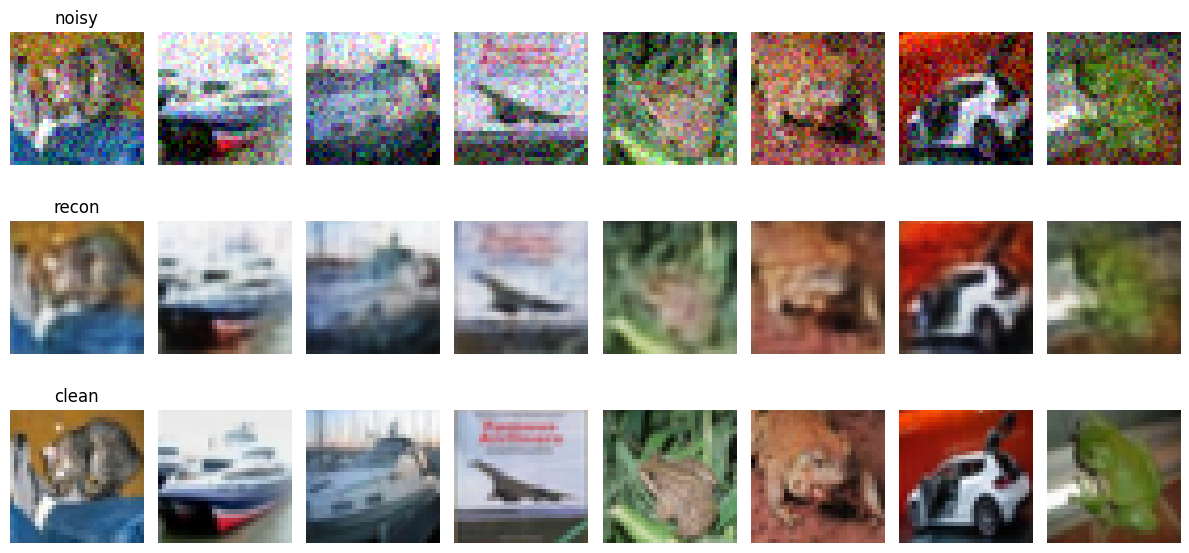

In [5]:
model.eval()

# 逆正規化用
mean = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(device)
std = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(device)

with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(device)
    imgs_noisy = add_noise(imgs)
    outputs = model(imgs_noisy)

# 可視化用にCPUへ
imgs_cpu = (imgs * std + mean).cpu()
noisy_cpu = (imgs_noisy * std + mean).cpu()
outputs_cpu = (outputs * std + mean).cpu()

n_show = 8
plt.figure(figsize=(12, 6))
for i in range(n_show):
    # ノイズ付き入力
    ax = plt.subplot(3, n_show, i + 1)
    plt.imshow(np.transpose(noisy_cpu[i].numpy(), (1, 2, 0)))
    plt.axis("off")
    if i == 0:
        ax.set_title("noisy")

    # 復元
    ax = plt.subplot(3, n_show, i + 1 + n_show)
    plt.imshow(np.transpose(outputs_cpu[i].numpy(), (1, 2, 0)))
    plt.axis("off")
    if i == 0:
        ax.set_title("recon")

    # 元画像
    ax = plt.subplot(3, n_show, i + 1 + 2 * n_show)
    plt.imshow(np.transpose(imgs_cpu[i].numpy(), (1, 2, 0)))
    plt.axis("off")
    if i == 0:
        ax.set_title("clean")

plt.tight_layout()
plt.show()

## 5. ボトルネック特徴量の抽出とk-meansクラスタリング（k=5,10）

CIFAR-10からランダムに100枚を選び、ボトルネック特徴量をflattenしてk-meansを実行します。

In [6]:
# ランダムに100枚抽出
num_samples = 100
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

subset_imgs = torch.stack([test_dataset[i][0] for i in indices]).to(device)

# ボトルネック特徴量の抽出
model.eval()
with torch.no_grad():
    bottleneck = model.encoder(subset_imgs)

features = bottleneck.view(num_samples, -1).cpu().numpy()

# k-means
k_list = [5, 10]
cluster_results = {}

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(features)
    cluster_results[k] = labels
    unique, counts = np.unique(labels, return_counts=True)
    print("k=", k, "counts:", dict(zip(unique, counts)))

k= 5 counts: {0: 3, 1: 34, 2: 11, 3: 16, 4: 36}
k= 10 counts: {0: 2, 1: 12, 2: 2, 3: 23, 4: 25, 5: 18, 6: 7, 7: 4, 8: 3, 9: 4}


## 6. クラスタ代表画像の可視化と考察用出力

各クラスタから代表画像（先頭数枚）を可視化し、似ている画像がグループ化されるかを確認します。

/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2913443/3629393114.py:25: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from current font.
  plt.tight_layout()
/tmp/ipyker

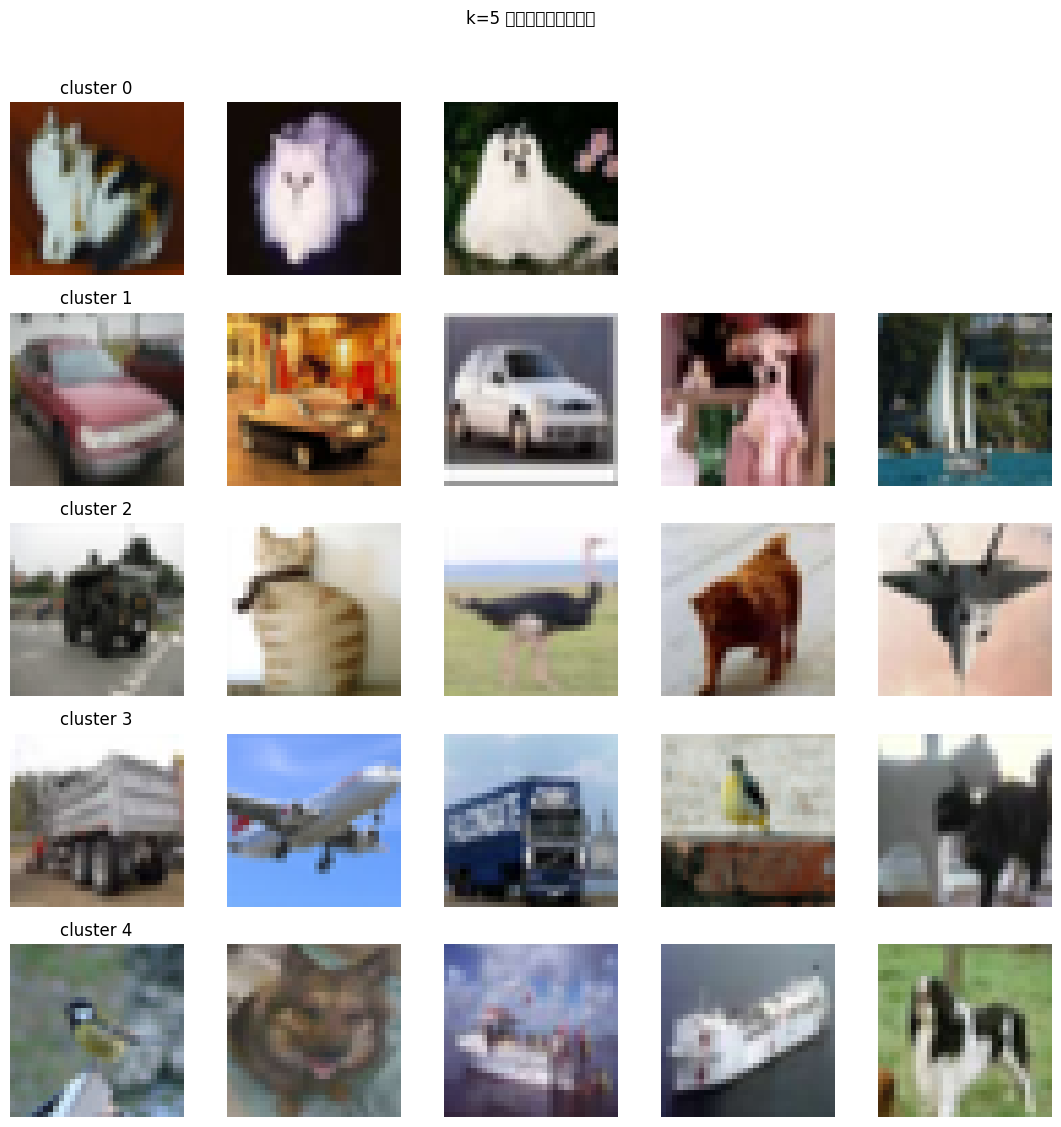

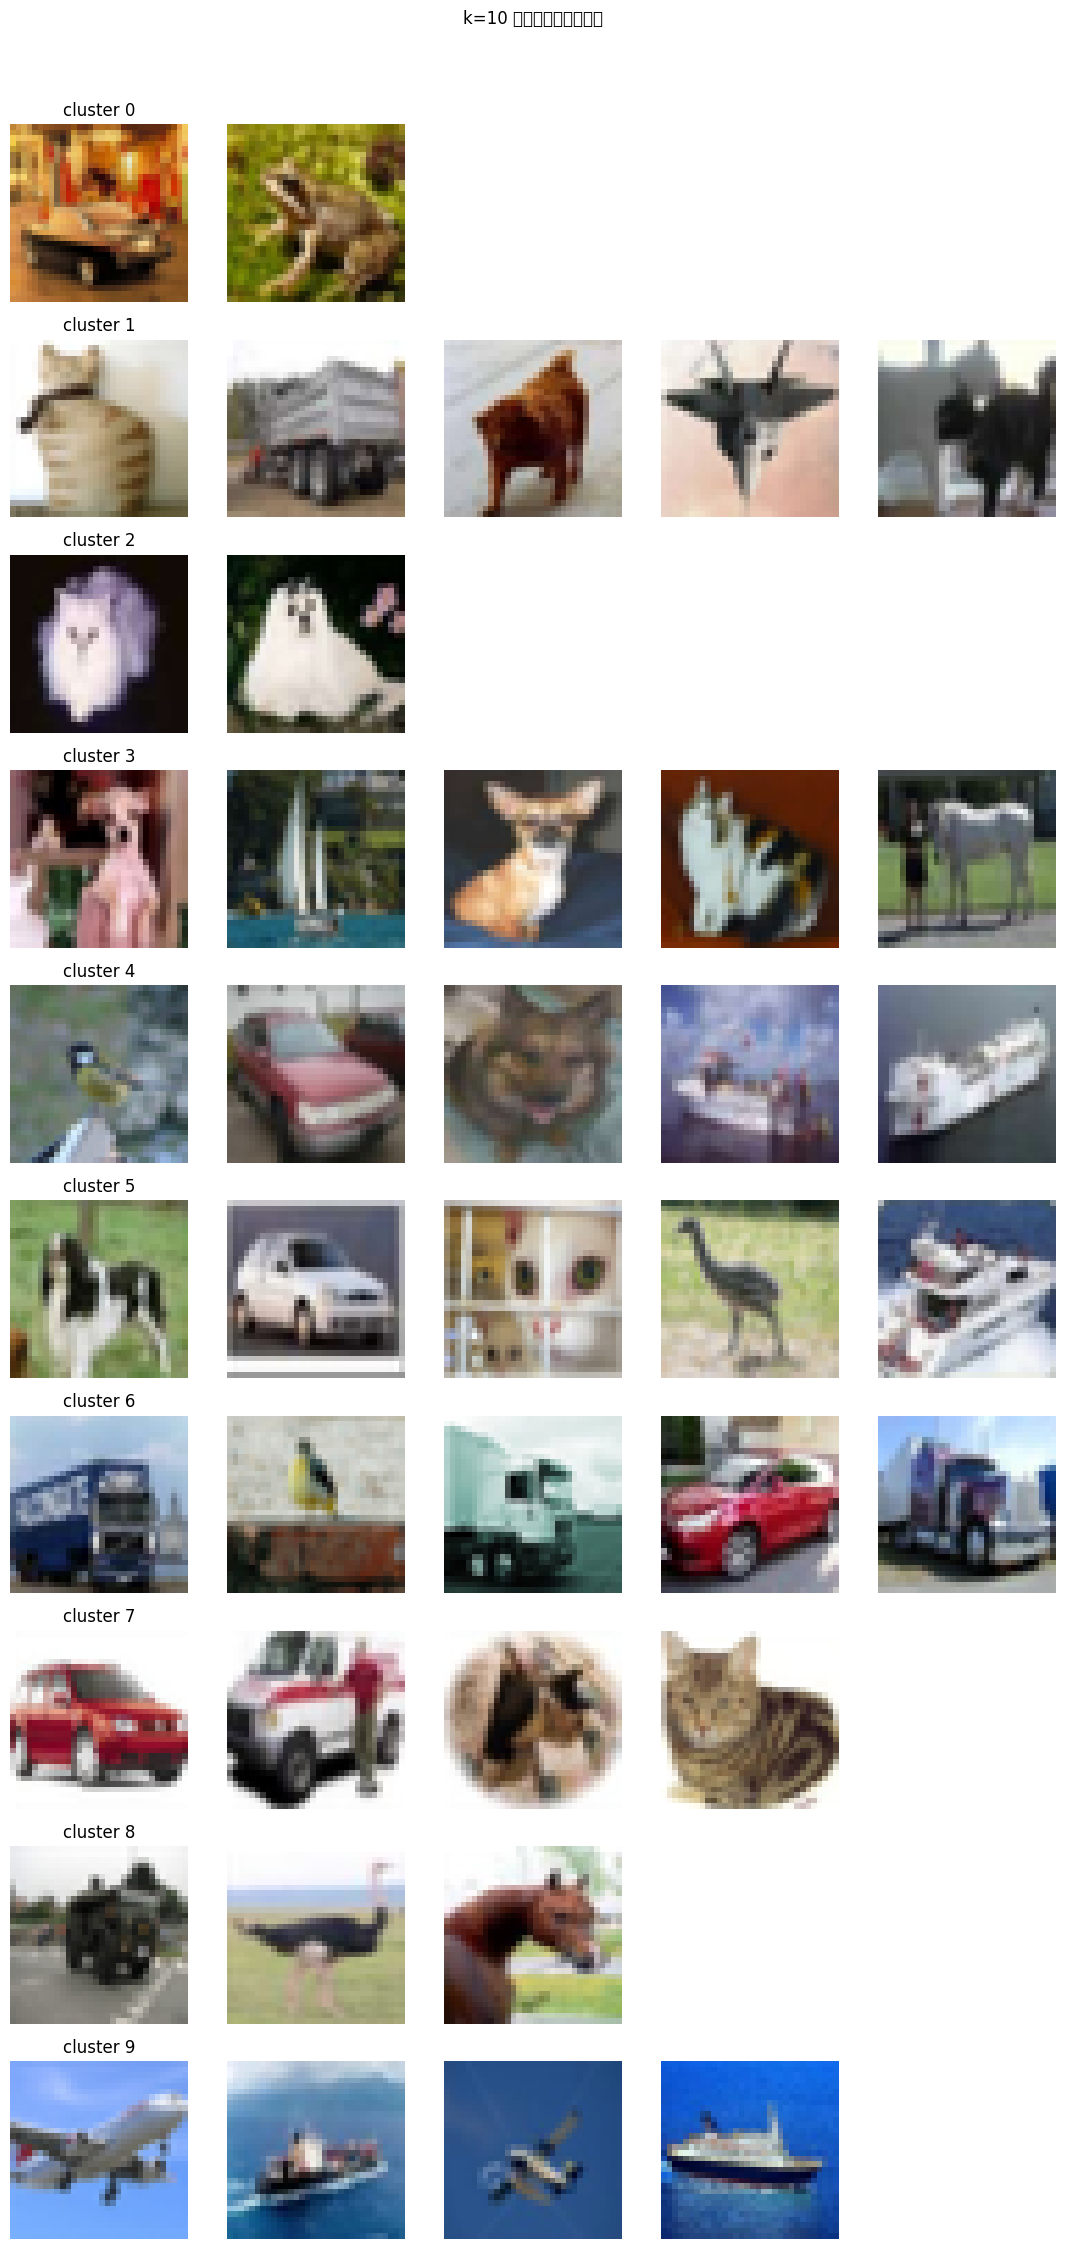

In [7]:
def denorm(x):
    return (x * std + mean).cpu()

# 可視化用にCPUへ
subset_imgs_cpu = denorm(subset_imgs)

for k in k_list:
    labels = cluster_results[k]
    n_cols = 5
    n_rows = k
    plt.figure(figsize=(n_cols * 2.2, n_rows * 2.2))
    plt.suptitle(f"k={k} クラスタの代表画像", y=1.02)

    for cluster_id in range(k):
        # 各クラスタの先頭サンプルを取得
        idxs = np.where(labels == cluster_id)[0][:n_cols]
        for j, idx in enumerate(idxs):
            ax = plt.subplot(n_rows, n_cols, cluster_id * n_cols + j + 1)
            img = subset_imgs_cpu[idx].numpy()
            plt.imshow(np.transpose(img, (1, 2, 0)))
            plt.axis("off")
            if j == 0:
                ax.set_title(f"cluster {cluster_id}")

    plt.tight_layout()
    plt.show()